# EDA for `final_training_dataset.parquet`

Exploratory data analysis for the final training dataset that will be used for synthetic data generation with diffusion models.

In [ ]:
pip install seaborn # type: ignore

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\lefte\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_training_dataset.parquet"

print(DATA_PATH)
print(DATA_PATH.exists())

C:\Users\lefte\Desktop\GitHub Projects\Thesis_project\data\processed\final_training_dataset.parquet
True


In [4]:
df = pd.read_parquet(DATA_PATH)
print(df.shape)
df.head()

(2000000, 16)


,rideable_type,started_at,member_casual,city,trip_duration,same_station,day_of_week,month,is_weekend,part_of_day,hour_sin,hour_cos,haversine_distance_km,bearing_sin,bearing_cos,hour
0,classic_bike,2025-01-20 17:50:29.907,member,chicago,11.4833,0,0,1,0,evening_peak,-0.9659,-0.2588,2.3244,0.9722,-0.2341,17
1,classic_bike,2025-01-02 16:35:51.494,member,chicago,3.9000,0,3,1,0,evening_peak,-0.8660,-0.5000,0.6676,0.9747,-0.2235,16
2,classic_bike,2025-01-08 18:11:32.334,member,chicago,2.6667,0,2,1,0,evening_peak,-1.0000,-0.0000,0.4719,0.6360,-0.7717,18
3,classic_bike,2025-01-17 16:56:25.216,member,chicago,6.2333,0,4,1,0,evening_peak,-0.8660,-0.5000,1.2144,0.2582,-0.9661,16
4,classic_bike,2025-01-03 18:39:50.561,member,chicago,8.3667,0,4,1,0,evening_peak,-1.0000,-0.0000,1.3157,1.0000,0.0010,18


## Basic structure

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   rideable_type          object        
 1   started_at             datetime64[us]
 2   member_casual          object        
 3   city                   object        
 4   trip_duration          float64       
 5   same_station           int32         
 6   day_of_week            int32         
 7   month                  int32         
 8   is_weekend             int32         
 9   part_of_day            object        
 10  hour_sin               float64       
 11  hour_cos               float64       
 12  haversine_distance_km  float64       
 13  bearing_sin            float64       
 14  bearing_cos            float64       
 15  hour                   int32         
dtypes: datetime64[us](1), float64(6), int32(5), object(4)
memory usage: 206.0+ MB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
rideable_type,2000000,2,electric_bike,1341471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
started_at,2000000,NaN,NaN,NaN,2025-07-16 15:20:09.292655,2024-12-31 23:22:57.682000,2025-05-15 11:15:31.938750,2025-07-22 19:47:51.222500,2025-09-22 17:36:54.624250,2025-12-31 23:52:00.371000,NaN
member_casual,2000000,2,member,1477208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,2000000,2,chicago,1000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trip_duration,"2,000,000.0000",NaN,NaN,NaN,12.6243,1.0167,5.4333,9.2000,15.8000,99.9833,11.3332
same_station,"2,000,000.0000",NaN,NaN,NaN,0.0239,0.0000,0.0000,0.0000,0.0000,1.0000,0.1528
day_of_week,"2,000,000.0000",NaN,NaN,NaN,2.9871,0.0000,1.0000,3.0000,5.0000,6.0000,1.9494
month,"2,000,000.0000",NaN,NaN,NaN,6.9916,1.0000,5.0000,7.0000,9.0000,12.0000,2.8185
is_weekend,"2,000,000.0000",NaN,NaN,NaN,0.2731,0.0000,0.0000,0.0000,1.0000,1.0000,0.4455
part_of_day,2000000,4,evening_peak,656199,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing = df.isna().sum().sort_values(ascending=False).to_frame("missing_values")
missing["missing_pct"] = 100 * missing["missing_values"] / len(df)
missing

,missing_values,missing_pct
rideable_type,0,0.0000
started_at,0,0.0000
member_casual,0,0.0000
city,0,0.0000
trip_duration,0,0.0000
same_station,0,0.0000
day_of_week,0,0.0000
month,0,0.0000
is_weekend,0,0.0000
part_of_day,0,0.0000


## Dataset balance

In [8]:
df["city"].value_counts(dropna=False).to_frame("n_rows")

,n_rows
city,
chicago,1000000
nyc,1000000


In [9]:
categorical_cols = ["city", "rideable_type", "member_casual", "part_of_day", "is_weekend", "same_station", "month", "day_of_week", "hour"]

for col in categorical_cols:
    display(df[col].value_counts(dropna=False).to_frame(name="count"))

,count
city,
chicago,1000000
nyc,1000000


,count
rideable_type,
electric_bike,1341471
classic_bike,658529


,count
member_casual,
member,1477208
casual,522792


,count
part_of_day,
evening_peak,656199
midday,575601
morning_peak,450845
night,317355


,count
is_weekend,
0,1453834
1,546166


,count
same_station,
0,1952157
1,47843


,count
month,
8,253291
7,245026
9,244489
6,225551
10,219745
5,185210
4,148918
11,138946
3,123527


,count
day_of_week,
4,306441
3,298909
5,296120
1,293083
2,288920
0,266481
6,250046


,count
hour,
17,196091
18,169396
16,166555
15,136620
19,124157
8,122821
14,119025
13,112808
12,110115


## Numeric summaries by city

In [10]:
numeric_cols = [
    "trip_duration",
    "haversine_distance_km",
    "hour",
    "hour_sin",
    "hour_cos",
    "bearing_sin",
    "bearing_cos",
]

df.groupby("city")[numeric_cols].agg(["mean", "median", "std", "min", "max"]).round(4)

trip_duration                               haversine_distance_km  \
                 mean median     std    min     max                  mean   
city                                                                        
chicago       13.4186 9.6500 12.2777 1.0167 99.9667                2.2551   
nyc           11.8300 8.7667 10.2410 1.0167 99.9833                1.9835   

                                        hour                        hour_sin  \
        median    std    min     max    mean  median    std min max     mean   
city                                                                           
chicago 1.6726 1.8594 0.0000 11.9996 13.9933 15.0000 4.9435   0  23  -0.2907   
nyc     1.4924 1.6473 0.0000 11.9951 14.0392 15.0000 5.1007   0  23  -0.2760   

                                      hour_cos                                \
         median    std     min    max     mean  median    std     min    max   
city                                                                           
chicago -0.5000 0.6980 -1.0000 1.0000  -0.3138 -0.5000 0.5743 -1.0000 1.0000   
nyc     -0.5000 0.6978 -1.0000 1.0000  -0.2852 -0.5000 0.5962 -1.0000 1.0000   

        bearing_sin                              bearing_cos                \
               mean median    std     min    max        mean median    std   
city                                                                         
chicago     -0.0098 0.0000 0.6359 -1.0000 1.0000      0.0413 0.0326 0.7706   
nyc         -0.0036 0.0000 0.6493 -1.0000 1.0000      0.0194 0.0440 0.7603   

                        
            min    max  
city                    
chicago -1.0000 1.0000  
nyc     -1.0000 1.0000

In [11]:
df.groupby("city")[["trip_duration", "haversine_distance_km"]].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).round(4)

trip_duration  haversine_distance_km
city                                                
chicago 0.0100         1.6667                 0.0000
        0.0500         2.8000                 0.3605
        0.2500         5.7167                 1.0022
        0.5000         9.6500                 1.6726
        0.7500        16.5833                 2.9419
        0.9500        36.9500                 6.0734
        0.9900        65.5500                 9.0539
nyc     0.0100         1.4500                 0.0000
        0.0500         2.4167                 0.3197
        0.2500         5.1667                 0.8595
        0.5000         8.7667                 1.4924
        0.7500        15.0333                 2.5895
        0.9500        31.3667                 5.3571
        0.9900        51.2500                 7.9624

## Distribution plots

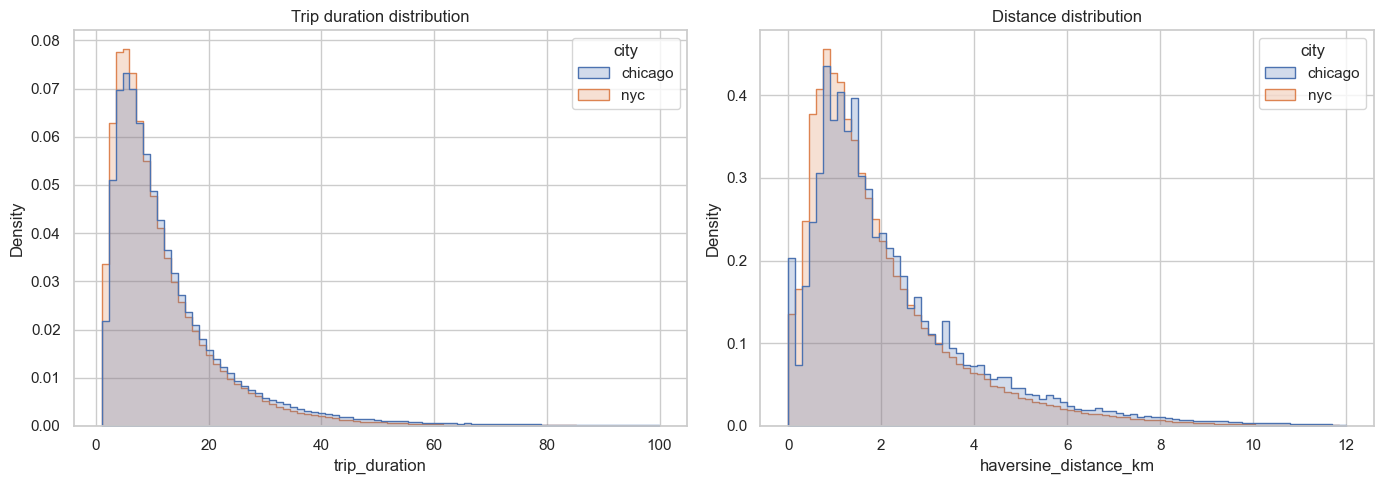

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x="trip_duration", hue="city", bins=80, stat="density", common_norm=False, element="step", ax=axes[0])
axes[0].set_title("Trip duration distribution")

sns.histplot(data=df, x="haversine_distance_km", hue="city", bins=80, stat="density", common_norm=False, element="step", ax=axes[1])
axes[1].set_title("Distance distribution")

plt.tight_layout()

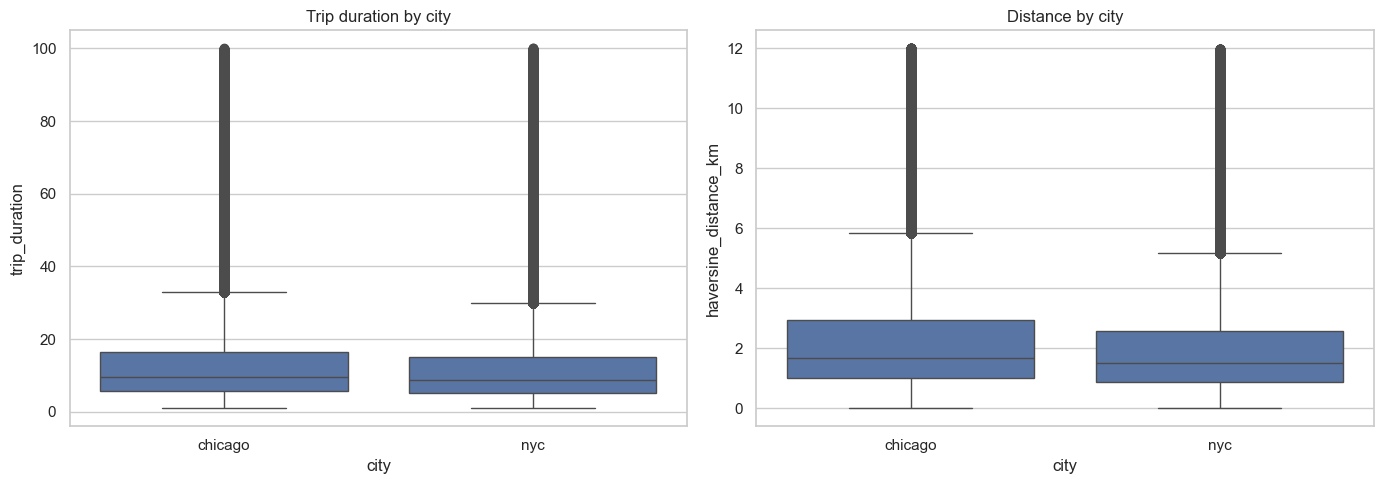

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="city", y="trip_duration", ax=axes[0])
axes[0].set_title("Trip duration by city")

sns.boxplot(data=df, x="city", y="haversine_distance_km", ax=axes[1])
axes[1].set_title("Distance by city")

plt.tight_layout()

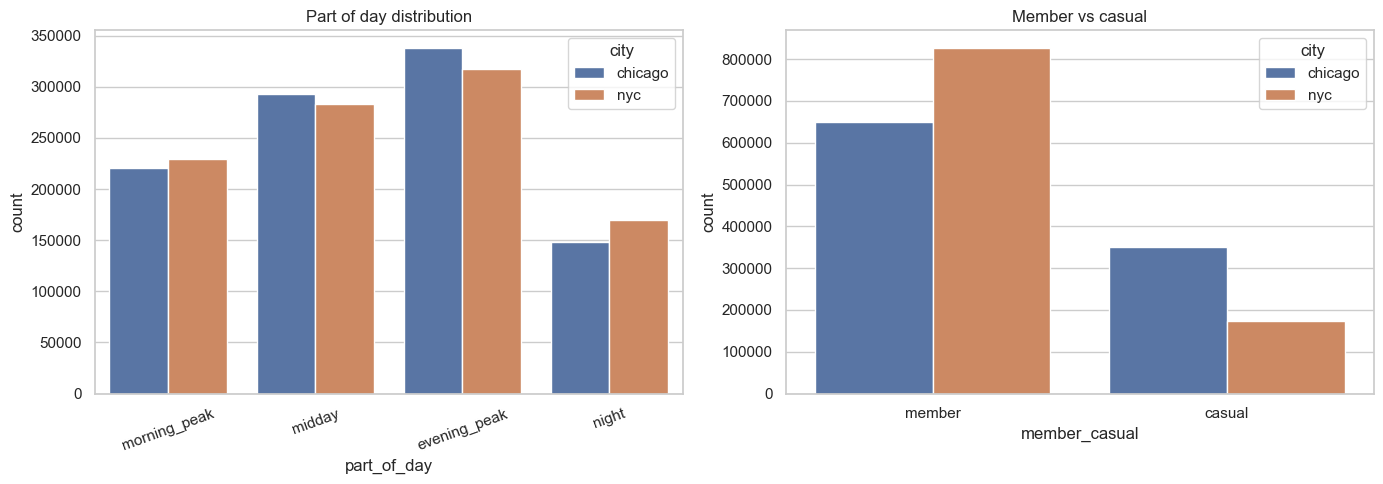

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="part_of_day", hue="city", ax=axes[0], order=["morning_peak", "midday", "evening_peak", "night"])
axes[0].set_title("Part of day distribution")
axes[0].tick_params(axis="x", rotation=20)

sns.countplot(data=df, x="member_casual", hue="city", ax=axes[1])
axes[1].set_title("Member vs casual")

plt.tight_layout()

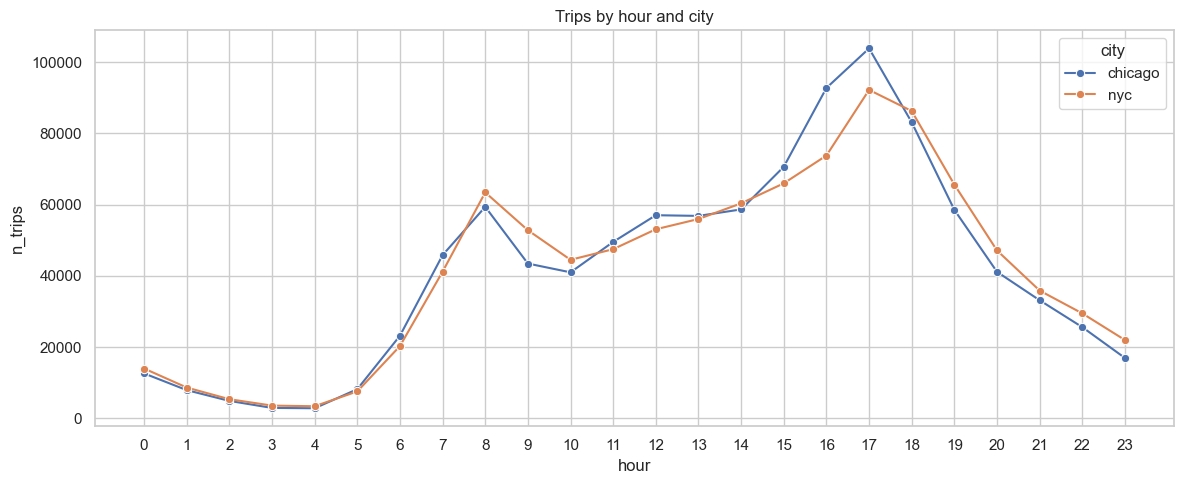

In [15]:
hour_city = df.groupby(["city", "hour"]).size().reset_index(name="n_trips")

plt.figure(figsize=(12, 5))
sns.lineplot(data=hour_city, x="hour", y="n_trips", hue="city", marker="o")
plt.title("Trips by hour and city")
plt.xticks(range(24))
plt.tight_layout()

## Correlations and feature sanity checks

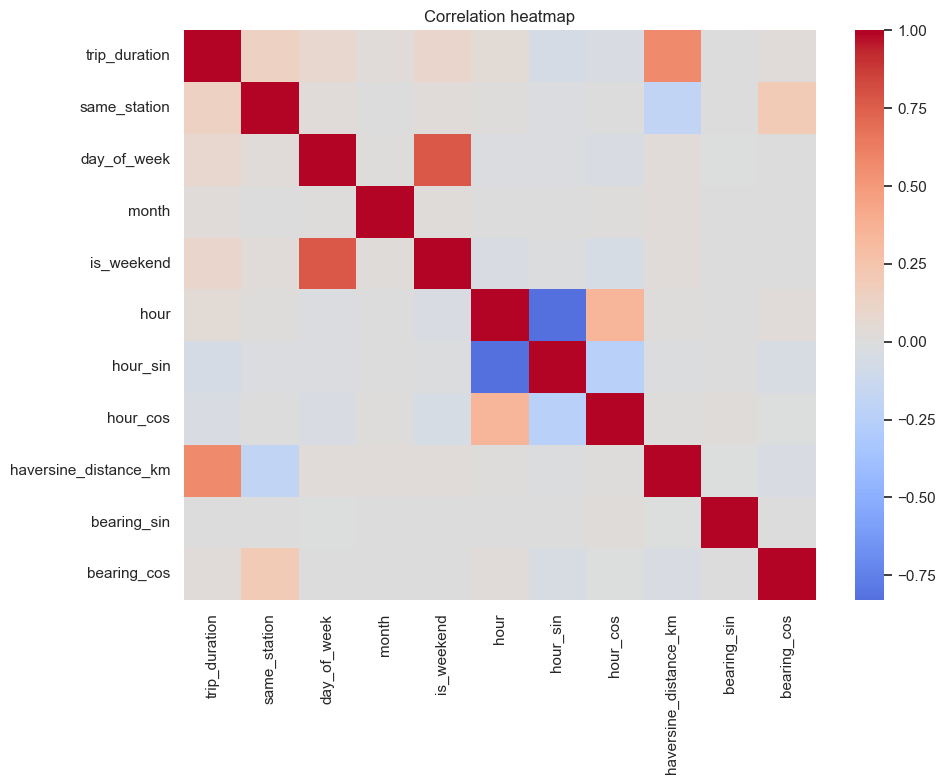

In [16]:
corr_cols = [
    "trip_duration",
    "same_station",
    "day_of_week",
    "month",
    "is_weekend",
    "hour",
    "hour_sin",
    "hour_cos",
    "haversine_distance_km",
    "bearing_sin",
    "bearing_cos",
]

corr = df[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()

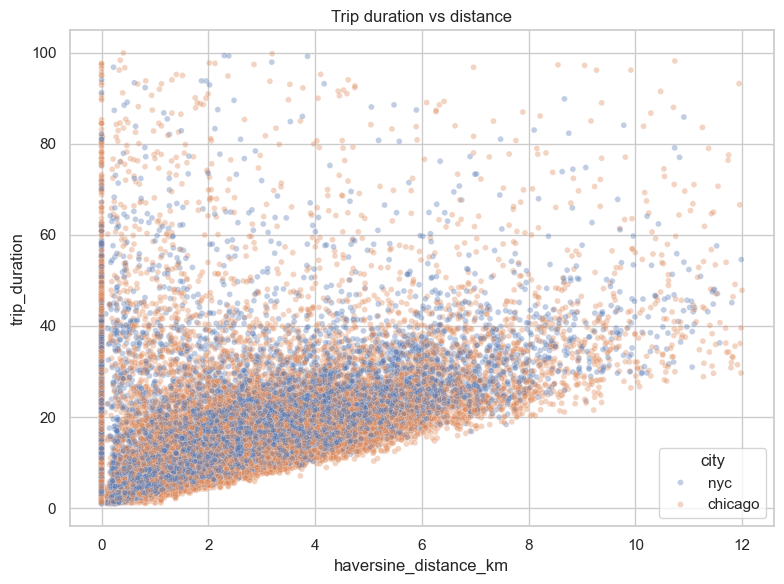

In [17]:
sample_df = df.sample(min(50000, len(df)), random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sample_df,
    x="haversine_distance_km",
    y="trip_duration",
    hue="city",
    alpha=0.35,
    s=18,
)
plt.title("Trip duration vs distance")
plt.tight_layout()

## DuckDB summaries

In [18]:
con = duckdb.connect()

query = f"""
SELECT
    city,
    COUNT(*) AS n_rows,
    AVG(trip_duration) AS avg_duration,
    MEDIAN(trip_duration) AS median_duration,
    AVG(haversine_distance_km) AS avg_distance,
    MEDIAN(haversine_distance_km) AS median_distance,
    AVG(same_station) AS same_station_rate
FROM read_parquet('{DATA_PATH.as_posix()}')
GROUP BY city
ORDER BY city
"""

con.execute(query).fetchdf()

,city,n_rows,avg_duration,median_duration,avg_distance,median_distance,same_station_rate
0,chicago,1000000,13.4186,9.6500,2.2551,1.6726,0.0284
1,nyc,1000000,11.8300,8.7667,1.9835,1.4924,0.0194


In [19]:
query = f"""
SELECT
    city,
    member_casual,
    rideable_type,
    COUNT(*) AS n_rows,
    AVG(trip_duration) AS avg_duration,
    AVG(haversine_distance_km) AS avg_distance
FROM read_parquet('{DATA_PATH.as_posix()}')
GROUP BY city, member_casual, rideable_type
ORDER BY city, member_casual, rideable_type
"""

con.execute(query).fetchdf()

,city,member_casual,rideable_type,n_rows,avg_duration,avg_distance
0,chicago,casual,classic_bike,121543,21.7775,2.0802
1,chicago,casual,electric_bike,228632,14.3972,2.3150
2,chicago,member,classic_bike,240703,12.5881,1.9607
3,chicago,member,electric_bike,409122,10.8771,2.4467
4,nyc,casual,classic_bike,42856,19.1995,1.9077
5,nyc,casual,electric_bike,129761,15.9905,2.2591
6,nyc,member,classic_bike,253427,10.5281,1.4881
7,nyc,member,electric_bike,573956,10.9139,2.1456


In [20]:
con.close()